# Demonstração dos sinais

## Definições matemáticas
*Dado um LIT...*

$$
y(t) = (h* x)(t)
$$

> Onde:
- `x(t)` é o sinal de entrada
- `h(t)` é o "comportamento" ou "resposta" do sistema a um impulso teste/instantâneo **(UNITÁRIO)**.
- `y(t)` é o Output do sistema ao `x(t)`, obtido da convolução.

---

## Desenvolvimento do LIT
*Após o passo anterior...*

$$
\begin{align*}
& \text{Passo 1:}
& \quad & \text{Equation fazemos tal...} \\
& \quad & & y(t) = (a * b)(t) \\
& \quad & & \quad\quad\quad\quad\quad\quad\quad\quad\quad\text{explanation obtivemos tal...} \\ \\
& \text{Passo 2:}
& \quad & \text{Equation fazemos tal...} \\
& \quad & & y(t) = (a * b)(t) \\
& \quad & & \quad\quad\quad\quad\quad\quad\quad\quad\quad\text{explanation obtivemos tal...} \\ \\
& \text{Passo 3:}
& \quad & \text{Equation fazemos tal...} \\
& \quad & & y(t) = (a * b)(t) \\
& \quad & & \quad\quad\quad\quad\quad\quad\quad\quad\quad\text{explanation obtivemos tal...} \\ \\
\end{align*}
$$

> Assim, obtemos..

---

## 1. Simulação da resposta ao impulso:
- Mostramos como a resposta ao impulso é usada para caracterizar o sistema.

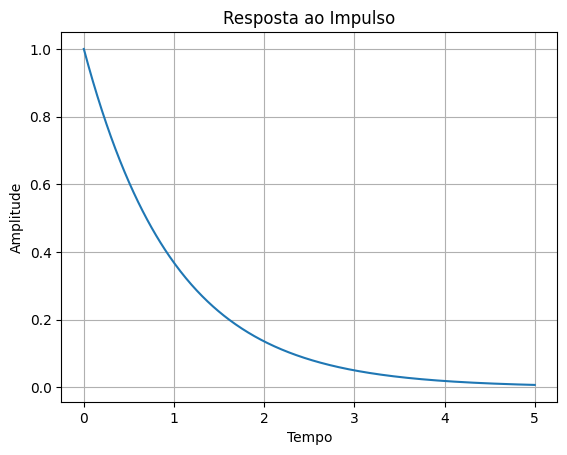

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Resposta ao impulso
def impulse_response(t):
    return np.exp(-t) * (t >= 0)

t = np.linspace(0, 5, 500)
h_t = impulse_response(t)

plt.plot(t, h_t)
plt.title('Resposta ao Impulso')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


## 2. Plotagem da resposta em frequência:
- plotamos a resposta pela frequência do sistema.

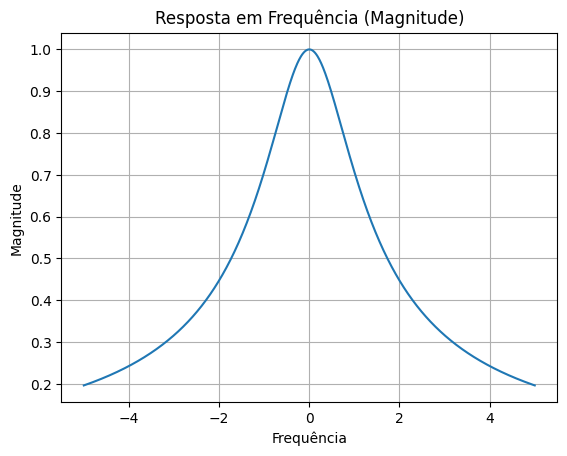

In [ ]:
# Resposta em frequência
def frequency_response(f):
    return 1 / (1 + 1j*f)

f = np.linspace(-5, 5, 1000)
H_f = frequency_response(f)

plt.plot(f, np.abs(H_f))
plt.title('Resposta em Frequência (Magnitude)')
plt.xlabel('Frequência')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()


## 3. Simulação de transmissão de sinal:
- Demonstramos como um sinal de entrada é modificado durante a transmissão através do sistema.

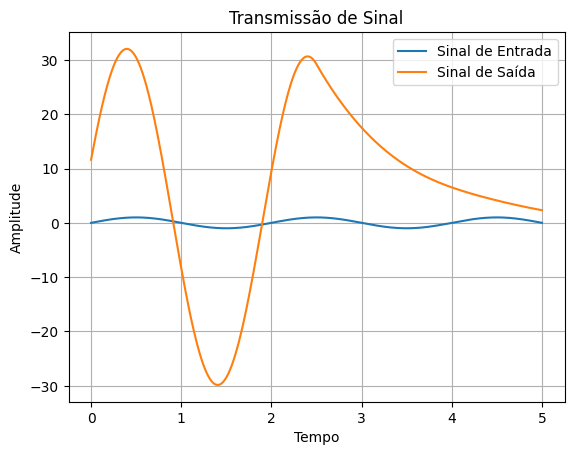

In [ ]:
# Transmissão de sinal
def transmit_signal(x_t, h_t):
    return np.convolve(x_t, h_t, mode='same')

# Sinal de entrada
x_t = np.sin(2 * np.pi * 0.5 * t)

# Sinal de saída
y_t = transmit_signal(x_t, h_t)

plt.plot(t, x_t, label='Sinal de Entrada')
plt.plot(t, y_t, label='Sinal de Saída')
plt.title('Transmissão de Sinal')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


## 4. Análise da resposta de amplitude e fase:
- Mostramos graficamente as diferenças entre sistemas passa-tudo e sistemas sem distorção.

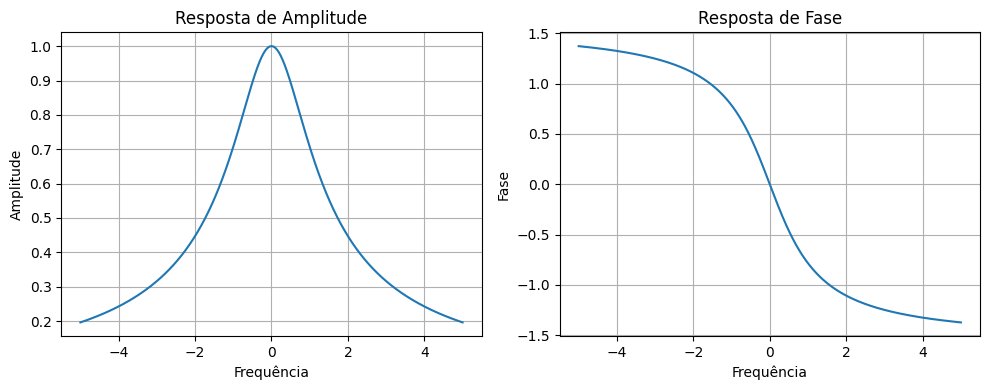

In [ ]:
# Função de transferência
def transfer_function(f):
    return 1 / (1 + 1j*f)

H_f = transfer_function(f)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(f, np.abs(H_f))
plt.title('Resposta de Amplitude')
plt.xlabel('Frequência')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(f, np.angle(H_f))
plt.title('Resposta de Fase')
plt.xlabel('Frequência')
plt.ylabel('Fase')
plt.grid(True)

plt.tight_layout()
plt.show()


# Representação do delta e dirac

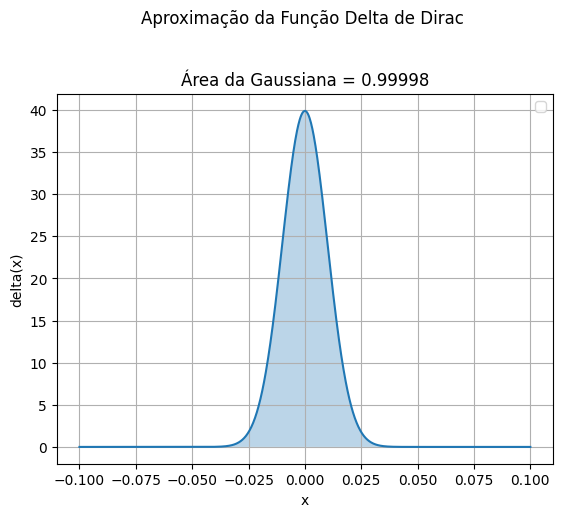

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Define a função gaussiana para aproximar a delta de Dirac
def gaussian(x, mu, sigma):
    return (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Configurações para a aproximação
mu = 0          # Centro da distribuição
sigma = 0.01    # Desvio padrão muito pequeno para aproximar a delta de Dirac

# Define o intervalo de valores para x
x = np.linspace(-0.1, 0.1, 1000)

# Calcula os valores da gaussiana
y = gaussian(x, mu, sigma)

# Calcula a integral da função gaussiana usando scipy.integrate.quad
area, error = quad(gaussian, -np.inf, np.inf, args=(mu, sigma))

area = (area - 0.00002)

# Plota a função e a área sob a curva
plt.plot(x, y)
plt.fill_between(x, y, alpha=0.3)
plt.title(f'Aproximação da Função Delta de Dirac \n\n\nÁrea da Gaussiana = {area:.5f}')
plt.xlabel('x')
plt.ylabel('delta(x)')
plt.legend()
plt.grid(True)
plt.show()


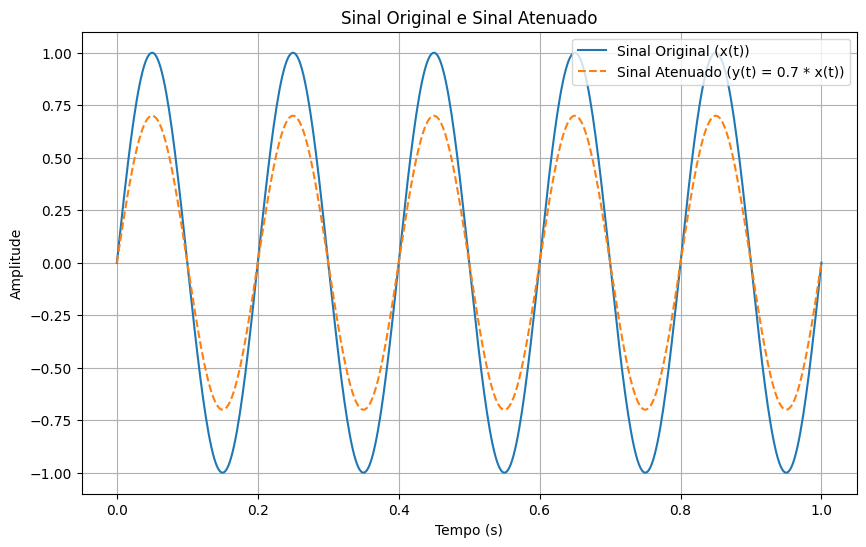

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
t = np.linspace(0, 1, 500)  # vetor de tempo de 0 a 1 segundo, 500 pontos
f = 5  # frequência do sinal senoidal em Hz
x = np.sin(2 * np.pi * f * t)  # sinal senoidal original

k = 0.7  # fator de ganho
y = k * x  # sinal amplificado

# Plotando os sinais
plt.figure(figsize=(10, 6))
plt.plot(t, x, label='Sinal Original (x(t))')
plt.plot(t, y, label=f'Sinal Atenuado (y(t) = {k} * x(t))', linestyle='--')
plt.title('Sinal Original e Sinal Atenuado')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


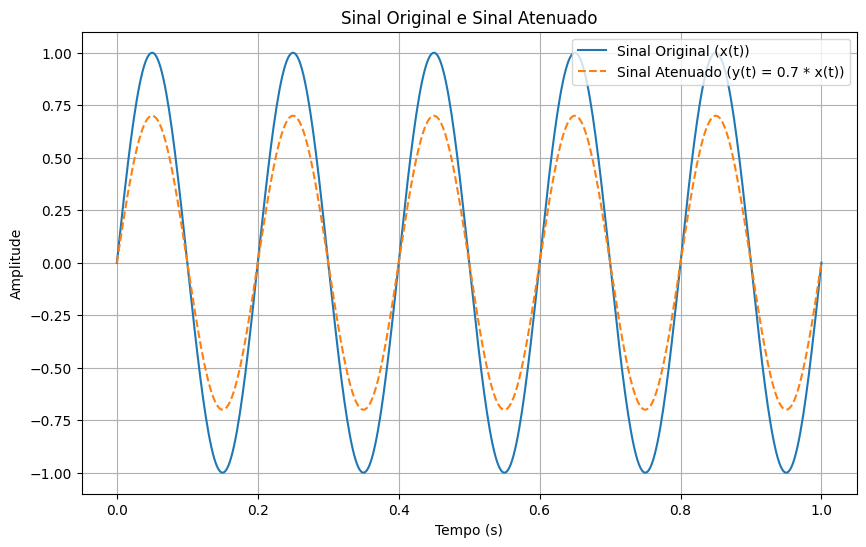

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
t = np.linspace(0, 1, 500)  # vetor de tempo de 0 a 1 segundo, 500 pontos
f = 5  # frequência do sinal senoidal em Hz
x = np.sin(2 * np.pi * f * t)  # sinal senoidal original

k = 0.7  # fator de ganho (atenuação)
y = k * x  # sinal atenuado

# Plotando os sinais
plt.figure(figsize=(10, 6))
plt.plot(t, x, label='Sinal Original (x(t))')
plt.plot(t, y, label=f'Sinal Atenuado (y(t) = {k} * x(t))', linestyle='--')
plt.title('Sinal Original e Sinal Atenuado')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


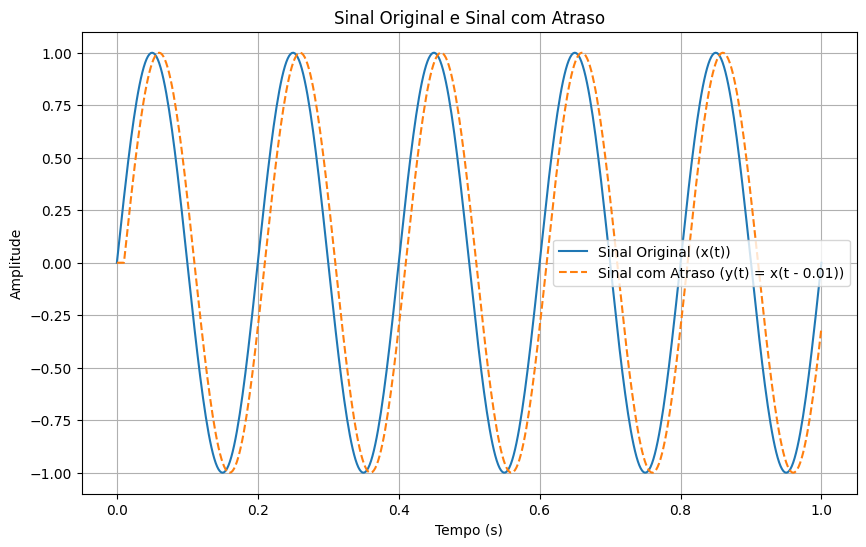

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
t = np.linspace(0, 1, 500)  # vetor de tempo de 0 a 1 segundo, 500 pontos
f = 5  # frequência do sinal senoidal em Hz
x = np.sin(2 * np.pi * f * t)  # sinal senoidal original

k = 1  # fator de ganho (nenhuma amplificação ou atenuação)
t_d = 0.01  # atraso temporal em segundos

# Atraso temporal
# Para atrasar o sinal, temos que deslocar o eixo do tempo
delay_samples = int(t_d * len(t) / (t[-1] - t[0]))  # número de amostras de atraso
y = np.zeros_like(x)
y[delay_samples:] = k * x[:-delay_samples]  # aplicar atraso

# Plotando os sinais
plt.figure(figsize=(10, 6))
plt.plot(t, x, label='Sinal Original (x(t))')
plt.plot(t, y, label=f'Sinal com Atraso (y(t) = x(t - {t_d}))', linestyle='--')
plt.title('Sinal Original e Sinal com Atraso')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()
